In [1]:
# importing packages
import pyomo.environ as pyo
import numpy as np
from matplotlib import pyplot as plt
import math
import scipy.stats as stats
from scipy.optimize import fsolve, bisect, minimize
import pandas as pd
import conductivity as cd
from scipy.optimize import brute
from matplotlib.ticker import MaxNLocator

# Determining the Best Cation Ratio for Three-Salt System Experiments

## Load the data

In [2]:
data = pd.read_csv("./Data/Three_salts_cation_ratio.csv")
NaCl_conc_raw = data["NaCl_conc"]
CaCl2_conc_raw = data["CaCl2_conc"]
LaCl3_conc_raw = data["LaCl3_conc"]

# number of data points
ndata = len(NaCl_conc_raw)

print(data)

   NaCl_conc  CaCl2_conc  LaCl3_conc
0          1           1           2
1          2           2           4
2          3           3           6
3          4           4           8
4          5           5          10
5          6           6          12
6          7           7          14
7          8           8          16
8          9           9          18
9         10          10          20


## MSA Transport model constants in SI units

In [3]:
# temperature in K
temp = 298.15

# diffusion coefficients at infinite dilution in m^2/s
Diff_Na = 1.334 * 10**(-9)
Diff_Cl = 2.032 * 10**(-9)
Diff_Ca = 0.792 * 10**(-9)
Diff_La = 0.619 * 10**(-9)
diffusion_coeff = [Diff_La, Diff_Ca, Diff_Na, Diff_Cl] 

# valencies
z_Na = 1
z_Cl = -1
z_Ca = 2
z_La = 3
valency = [z_La, z_Ca, z_Na, z_Cl]

# sensor voltage in V and probe distance in m
voltage = 25 * 10**(-3)
distance = 9 * 10**(-6)

# hard sphere diameters in m
sigma_Cl = 2 * 181 * 10**(-12)
sigma_Ca = 2 * 100 * 10**(-12)
sigma_La = 2 * 118 * 10**(-12)
sigma_Na = 2 * 102 * 10**(-12)
diameter = [sigma_La, sigma_Ca, sigma_Na, sigma_Cl]

# solvent viscosity in Pa.s
eta_msa = 0.89 * 10**(-3)

# relative permittivity
epsilon = 78.43

# limiting molar conductivity of ions in m^2.S/mol
lambda_0_Na_mol = 50.08 * 10**(-4)
lambda_0_Cl_mol = 76.31 * 10**(-4)
lambda_0_Ca_mol = 59.47 * 10**(-4)
lambda_0_La_mol = 69.7 * 10**(-4)
lambda_0_La_Ca_Na_Cl = [lambda_0_La_mol, lambda_0_Ca_mol, lambda_0_Na_mol, lambda_0_Cl_mol]

## Variant Shedlovsky model constants

In [4]:
# solvent viscosity in poise
eta_shed = 8.903*10**(-3)

# limiting equivalent conductivity of salts in cm^2.Siemen.equiv^(-1)
lambda_0_NaCl = 126.45 
lambda_0_CaCl2 = 135.85
lambda_0_LaCl3 = 145.9

# limiting equivalent conductivity of ions in cm^2.Siemen.equiv^(-1)
lambda_0_Na = 50.10 
lambda_0_Ca = 59.5
lambda_0_La = 69.7
lambda_0_Cl = 76.35

# distance from an ion within which no other ion can penetrate in cm
a_NaCl = 4*10**(-8)
a_CaCl2 = 4.31*10**(-8)
a_LaCl3 = 4.9*10**(-8)

## Validate the models with two-salt data

In [5]:
validation_data = pd.read_csv("./Data/NaCl_LaCl3_rearranged.csv")
NaCl_conc22 = validation_data["NaCl conc2"]
LaCl3_conc22 = validation_data["LaCl3 conc2"]
cond_exp = validation_data["Cal bulk cond2"]
print(cond_exp)

# diffusion coefficients, valencies, and hard sphere diameters of the two salts system
diffusion_coeff_2 = [Diff_La, Diff_Na, Diff_Cl]
valency_2 = [z_La, z_Na, z_Cl]
diameter_2 = [sigma_La, sigma_Na, sigma_Cl]
lambda_0_La_Na_Cl = [lambda_0_La_mol, lambda_0_Na_mol, lambda_0_Cl_mol]
a = (a_NaCl + a_LaCl3)/2

# evaluate the salts concentration in mM using the cation ratio
conc_NaCl_msa = [6*NaCl_conc_raw[i] for i in range(ndata)]

# evaluate the salts concentration in M using the cation ratio
conc_NaCl_shed = [conc_NaCl_msa[i]*10**(-3) for i in range(ndata)]
conc_LaCl3_shed = [LaCl3_conc_raw[i]*10**(-3) for i in range(ndata)]

# calculate the individual salt conductivity using the variant Shedlovsky model
variant_shed_cond_NaCl = cd.variant_shedlovsky(conc_NaCl_shed, temp, epsilon, eta_shed, lambda_0_NaCl, a, z_Na, z_Cl, 
                             lambda_0_Na, lambda_0_Cl)
variant_shed_cond_LaCl3 = cd.variant_shedlovsky(conc_LaCl3_shed, temp, epsilon, eta_shed, lambda_0_LaCl3, a, z_La, z_Cl, 
                             lambda_0_La, lambda_0_Cl)

# calculate the bulk conductivity using the variant Shedlovsky model
variant_shed_cond = [variant_shed_cond_NaCl[i] + variant_shed_cond_LaCl3[i] for i in range(ndata)] 

# calculate the bulk conductivity using the MSA transport model
msa_cond = cd.msa_transport(valency_2, diameter_2, diffusion_coeff_2, temp, eta_msa, epsilon, lambda_0_La_Na_Cl, LaCl3_conc_raw, conc_NaCl_msa)

sse = sum((msa_cond[i] - cond_exp[i])**2 for i in range(ndata))

err = [(msa_cond[i] - cond_exp[i])/msa_cond[i] for i in range(ndata)]
err_abs = [np.abs(err[i]) for i in range(ndata)]
print("MAPE",np.mean(err_abs))

print("The variant Shedlovsky:\n",variant_shed_cond)
print("MSA transport:\n",msa_cond)
print("SSE",sse)

0     1467.883721
1     2752.339767
2     4000.965581
3     5209.484651
4     6390.033023
5     7584.451163
6     8697.731163
7     9872.038140
8    10984.624650
9    12124.488370
Name: Cal bulk cond2, dtype: float64
Relaxation correction: [-0.17116259 -0.02670757 -0.09893508]
Hydrodynamic correction: [-0.40925151 -0.19314246 -0.1171157 ]
omega_bar: 293668709070.8091
Alpha: [0.0, 242876329097.13528, 388092787538.26306]
Mew: [0.5        0.16666667 0.33333333]
Transport number: [0.25596141 0.18387319 0.5601654 ]
Omega: [1.50335711e+11 3.23986816e+11 4.93509152e+11]
ksi: [[ 1.69629658 -0.98749428 -0.23296339]
 [ 0.78711213  1.6842391  -1.40795025]
 [ 0.51673602  0.63912188  1.0534202 ]]
MAPE 0.020757235331234646
The variant Shedlovsky:
 [1483.6887591090644, 2864.3562351305236, 4188.158227157195, 5470.507290133768, 6719.897842857054, 7941.830542973447, 9140.197040213245, 10317.912087125002, 11477.248024580847, 12620.030039097512]
MSA transport:
 [1430.8664142594344, 2732.0048114702, 3965.8

## Solve the Optimization Problem

### Validation of cation ratio with two-salt data

In [6]:
# create the objective function of the optimization problem
def SSE_validation(cation_ratio):
    """
    Calculates the sum of squared errors between the variant Shedlovsky and MSA Transport model

    Argument:
        cation_ratio: cation ratio of the salt"""

    # evaluate the salts concentration in mM using the cation ratio
    conc_NaCl = [cation_ratio*NaCl_conc_raw[i] for i in range(ndata)]

    # evaluate the salts concentration in M using the cation ratio
    conc_NaCl_shed = [conc_NaCl[i]*10**(-3) for i in range(ndata)]
    conc_LaCl3_shed = [LaCl3_conc_raw[i]*10**(-3) for i in range(ndata)]

    # calculate the individual salt conductivity using the variant Shedlovsky model
    variant_shed_cond_NaCl = cd.variant_shedlovsky(conc_NaCl_shed, temp, epsilon, eta_shed, lambda_0_NaCl, a, z_Na, z_Cl, 
                                 lambda_0_Na, lambda_0_Cl)
    variant_shed_cond_LaCl3 = cd.variant_shedlovsky(conc_LaCl3_shed, temp, epsilon, eta_shed, lambda_0_LaCl3, a, z_La, z_Cl, 
                                 lambda_0_La, lambda_0_Cl)

    # calculate the bulk conductivity using the variant Shedlovsky model
    variant_shed_cond = [variant_shed_cond_NaCl[i] + variant_shed_cond_LaCl3[i] for i in range(ndata)]

    # calculate the bulk conductivity using the MSA transport model
    msa_cond = cd.msa_transport(valency_2, diameter_2, diffusion_coeff_2, temp, eta_msa, epsilon, lambda_0_La_Na_Cl, LaCl3_conc_raw, conc_NaCl)

    # calculate the sum of squared errors between the variant Shedlovsky and MSA transport models
    sse = sum((msa_cond[i] - cond_exp[i])**2 for i in range(ndata))
    
    return sse

In [7]:
# Define bounds and step size for integers
ranges = (slice(1, 11, 1),)

# Run brute-force grid search
result = brute(SSE_validation, ranges=ranges, finish=None)

# Output
print("Best solution found for the cation ratio is:", result)
print("Objective value at best solution:", SSE_validation(result))

Relaxation correction: [-0.12637798 -0.01308509 -0.11019328]
Hydrodynamic correction: [-0.36243161 -0.17069429 -0.10443014]
omega_bar: 249407449467.97238
Alpha: [0.0, 296713649948.1031, 372366303979.31903]
Mew: [0.69230769 0.03846154 0.26923077]
Transport number: [0.41730337 0.04996255 0.53273408]
Omega: [1.50335711e+11 3.23986816e+11 4.93509152e+11]
ksi: [[ 1.44715366 -0.45169903 -0.31313326]
 [ 0.67150534  3.76294459 -2.32471958]
 [ 0.44084061  0.62394828  1.1373026 ]]
Relaxation correction: [-0.13744596 -0.01647846 -0.10720408]
Hydrodynamic correction: [-0.37274898 -0.17563275 -0.10724013]
omega_bar: 260788916222.98755
Alpha: [0.0, 280185123994.9613, 378474712351.47736]
Mew: [0.64285714 0.07142857 0.28571429]
Transport number: [0.37058471 0.08873811 0.54067718]
Omega: [1.50335711e+11 3.23986816e+11 4.93509152e+11]
ksi: [[ 1.50778913 -0.58944861 -0.27849707]
 [ 0.69964128  2.68345218 -1.89174574]
 [ 0.45931175  0.65539633  1.09955484]]
Relaxation correction: [-0.14726542 -0.01947212 

### Three-salt experiment cation ratio

In [8]:
a_Na_Ca_La = (a_NaCl + a_CaCl2 + a_LaCl3)/3

# create the objective function of the optimization problem
def SSE(cation_ratio):
    """
    Calculates the sum of squared errors between the variant Shedlovsky and MSA Transport model

    Argument:
        cation_ratio: list of the cation ratio of the salts"""

    # evaluate the salts concentration in mM using the cation ratio
    conc_NaCl = [cation_ratio[0]*NaCl_conc_raw[i] for i in range(ndata)]
    conc_CaCl2 = [cation_ratio[1]*CaCl2_conc_raw[i] for i in range(ndata)]

    # evaluate the salts concentration in M using the cation ratio
    conc_NaCl_shed = [conc_NaCl[i]*10**(-3) for i in range(ndata)]
    conc_CaCl2_shed = [conc_CaCl2[i]*10**(-3) for i in range(ndata)]
    conc_LaCl3_shed = [LaCl3_conc_raw[i]*10**(-3) for i in range(ndata)]

    # calculate the individual salt conductivity using the variant Shedlovsky model
    variant_shed_cond_NaCl = cd.variant_shedlovsky(conc_NaCl_shed, temp, epsilon, eta_shed, lambda_0_NaCl, a_Na_Ca_La, z_Na, z_Cl, 
                                 lambda_0_Na, lambda_0_Cl)
    variant_shed_cond_CaCl2 = cd.variant_shedlovsky(conc_CaCl2_shed, temp, epsilon, eta_shed, lambda_0_CaCl2, a_Na_Ca_La, z_Ca, z_Cl, 
                                 lambda_0_Ca, lambda_0_Cl)
    variant_shed_cond_LaCl3 = cd.variant_shedlovsky(conc_LaCl3_shed, temp, epsilon, eta_shed, lambda_0_LaCl3, a_Na_Ca_La, z_La, z_Cl, 
                                 lambda_0_La, lambda_0_Cl)

    # calculate the bulk conductivity using the variant Shedlovsky model
    variant_shed_cond = [variant_shed_cond_NaCl[i] + variant_shed_cond_CaCl2[i] + variant_shed_cond_LaCl3[i] for i in range(ndata)]

    # calculate the bulk conductivity using the MSA transport model
    msa_cond = cd.msa_transport(valency, diameter, diffusion_coeff, temp, eta_msa, epsilon, lambda_0_La_Ca_Na_Cl, LaCl3_conc_raw, conc_CaCl2, conc_NaCl)

    # calculate the sum of squared errors between the variant Shedlovsky and MSA transport models
    sse = sum((msa_cond[i] - variant_shed_cond[i])**2 for i in range(ndata))
    
    return sse

### Try Scipy minimize function

In [9]:
# initial guess of cation ratio
cation_ratio = [3, 3]

# solve the optimization problem
result = minimize(SSE, cation_ratio, bounds=[(1, 6), (1, 6)], method="L-BFGS-B")

# get the optimal cation ratio
opt_cation_ratio = result.x

# get the sse value at the optimal cation ratio
opt_sse = result.fun

print("The optimal cation ratio is:",opt_cation_ratio)
print("The objective function at the optimal is:",opt_sse)

Relaxation correction: [-0.18112685 -0.08424289 -0.02673774 -0.11149544]
Hydrodynamic correction: [-0.45658975 -0.36452458 -0.21590856 -0.12983571]
omega_bar: 278934675976.147
Alpha: [0.0, 172856559406.74725, 290001577279.39966, 375384664009.3576]
Mew: [0.375  0.25   0.0625 0.3125]
Transport number: [0.20211145 0.17239878 0.07259469 0.55289508]
Omega: [1.50335711e+11 1.92351992e+11 3.23986816e+11 4.93509152e+11]
ksi: [[ 1.63439298 -1.40422001 -0.47148858 -0.28703571]
 [ 1.27738542  1.83671414 -0.78767228 -0.41814481]
 [ 0.75838775  0.29334259  2.99475724 -2.03601072]
 [ 0.49787857  0.15702417  0.59697267  1.08616085]]
Relaxation correction: [-0.18112685 -0.08424289 -0.02673774 -0.11149544]
Hydrodynamic correction: [-0.45658975 -0.36452458 -0.21590856 -0.12983571]
omega_bar: 278934676030.23584
Alpha: [0.0, 172856559404.99518, 290001577203.6522, 375384664039.3267]
Mew: [0.375  0.25   0.0625 0.3125]
Transport number: [0.20211145 0.17239878 0.07259469 0.55289508]
Omega: [1.50335711e+11 1.9

### Use Scipy brute function (recommended)

In [10]:
# Define bounds and step size for integers
ranges = (slice(1, 7, 1), slice(1, 7, 1))

# Run brute-force grid search
opt_cation_ratio_int = brute(SSE, ranges=ranges, finish=None)

# get the sse value at the optimal cation ratio
opt_sse_int = SSE(opt_cation_ratio_int)

# Output
print("Best solution found for the cation ratio is:", opt_cation_ratio_int)
print("Objective value at best solution:", opt_sse_int)

Relaxation correction: [-0.1445827  -0.06104064 -0.01729417 -0.11187463]
Hydrodynamic correction: [-0.39288082 -0.31269002 -0.18527319 -0.11271869]
omega_bar: 257531873781.63416
Alpha: [0.0, 183116322854.86185, 302562938375.23364, 369832596041.1939]
Mew: [0.5625  0.125   0.03125 0.28125]
Transport number: [0.32836261 0.0933632  0.03931392 0.53896027]
Omega: [1.50335711e+11 1.92351992e+11 3.23986816e+11 4.93509152e+11]
ksi: [[ 1.50096741 -0.73185259 -0.38971956 -0.32406947]
 [ 1.17310458  2.95166376 -0.63026736 -0.4744769 ]
 [ 0.69647588  0.24133643  4.3137713  -2.50685801]
 [ 0.45723368  0.12503945  0.58025004  1.13755735]]
Relaxation correction: [-0.15852489 -0.06934379 -0.02048636 -0.11354644]
Hydrodynamic correction: [-0.41936697 -0.33419461 -0.19798597 -0.1198744 ]
omega_bar: 263090690417.29745
Alpha: [0.0, 177291329311.5861, 306198014447.22864, 368058818915.5673]
Mew: [0.47368421 0.21052632 0.02631579 0.28947368]
Transport number: [0.2706734  0.1539209  0.03240696 0.54299874]
Omeg

### Determine the best concentrations for future three-salt experiments given a desired ionic strength experiment

In [11]:
def three_salts_conc(LaCl3_conc, NaCl_conc, ionic_strength, fig_name):
    """
    Calculates the concentration of CaCl3 and the prediction difference between the Variant Shedlovsky and MSA models

    Arguments:
        LaCl3_conc: list or Pandas series of the concentration of LaCl3 in mM
        NaCl_conc: list or Pandas series of the concentration of NaCl in mM
        ionic_strength: int or float of the desired ionic strength of the three-salt solution

    Returns:
        residuals_percent: list of the prediction difference between the Variant Shedlovsky and MSA models
    """
    na_conc_plot = []
    la_conc_plot = []
    ca_conc_plot = []
    
    # save the results
    residuals_percent = []
    
    for conc_na in NaCl_conc:
        for conc_la in LaCl3_conc:
            conc_ca = (2 * ionic_strength - conc_na * z_Na * (z_Na + z_Cl**2) - conc_la * z_La * (z_La + z_Cl**2)) / (z_Ca * (z_Ca + z_Cl**2))
    
            # calculate the species ionic strength
            ionic_str_na = 0.5 * conc_na * z_Na**2
            ionic_str_la = 0.5 * conc_la * z_La**2
            ionic_str_ca = 0.5 * conc_ca * z_Ca**2
            ionic_str_cl = 0.5 * (z_Na * conc_na + z_Ca * conc_ca + z_La * conc_la) * z_Cl**2
        
            print("The concentration of NaCl is:",conc_na)
            print("The concentration of LaCl3 is:",conc_la)
            print("The concentration of CaCl2 is:",conc_ca)
            
            print("The ionic strength of Na+ is:",ionic_str_na)
            print("The ionic strength of La3+ is:",ionic_str_la)
            print("The ionic strength of Ca2+ is:",ionic_str_ca)
            print("The ionic strength of Cl- is:",ionic_str_cl)
            na_conc_plot.append(conc_na)
            la_conc_plot.append(conc_la)
            ca_conc_plot.append(conc_ca)
        
            # evaluate the salts concentration in M using the cation ratio
            conc_NaCl_shed = [conc_na * 10**(-3)]
            conc_CaCl2_shed = [conc_ca * 10**(-3)]
            conc_LaCl3_shed = [conc_la * 10**(-3)]
    
            # calculate the individual salt conductivity using the variant Shedlovsky model
            variant_shed_cond_NaCl = cd.variant_shedlovsky(conc_NaCl_shed, temp, epsilon, eta_shed, lambda_0_NaCl, a_Na_Ca_La, z_Na, z_Cl, 
                                         lambda_0_Na, lambda_0_Cl)
            variant_shed_cond_CaCl2 = cd.variant_shedlovsky(conc_CaCl2_shed, temp, epsilon, eta_shed, lambda_0_CaCl2, a_Na_Ca_La, z_Ca, z_Cl, 
                                         lambda_0_Ca, lambda_0_Cl)
            variant_shed_cond_LaCl3 = cd.variant_shedlovsky(conc_LaCl3_shed, temp, epsilon, eta_shed, lambda_0_LaCl3, a_Na_Ca_La, z_La, z_Cl, 
                                         lambda_0_La, lambda_0_Cl)
        
            # get the number of data
            ndata_all = len(variant_shed_cond_NaCl)
        
            # calculate the bulk conductivity using the variant Shedlovsky model
            variant_shed_cond = [variant_shed_cond_NaCl[i] + variant_shed_cond_CaCl2[i] + variant_shed_cond_LaCl3[i] for i in range(ndata_all)]
        
            # calculate the bulk conductivity using the MSA transport model
            msa_cond = cd.msa_transport(valency, diameter, diffusion_coeff, temp, eta_msa, epsilon, lambda_0_La_Ca_Na_Cl, 
                                        [conc_la], [conc_ca], [conc_na])
    
            # mean of the predictions which may be treated as data
            mean_cond_pred = [(msa_cond[i] + variant_shed_cond[i])/2 for i in range(ndata_all)]
        
            # calculate the residuals between the MSA transport and variant Shedlovksy models
            residuals = [variant_shed_cond[i] - msa_cond[i] for i in range(ndata_all)]
            residuals_per = [100 * residuals[i] / msa_cond[i] for i in range(ndata_all)]
        
            # calculate the mean absolute percent error
            abs_residuals_per = [np.abs(residuals_per[i]) for i in range(ndata_all)]
            mean_abs_residuals_per = np.mean(abs_residuals_per)
            
            residuals_percent.append([mean_abs_residuals_per])

    # plot the model difference results
    residuals_percent_array = np.asarray(residuals_percent)

    # X and Y axis labels
    x_label = "Concentration of Na$\mathbf{^{+}} (mM)$"
    y_label = "Concentration of La$\mathbf{^{3+}} (mM)$"
    data_res = np.zeros((len(residuals_percent_array), 3))
    data_res[:, 0] = na_conc_plot
    data_res[:, 1] = la_conc_plot
    data_res[:, 2] = residuals_percent_array[:, 0]

    plot_heatmap(data_res, y_label, x_label, "Model Prediction Difference (%)", fig_name)

    # plot the salt concentration results
    data_conc = np.zeros((len(ca_conc_plot), 3))
    data_conc[:, 0] = na_conc_plot
    data_conc[:, 1] = la_conc_plot
    data_conc[:, 2] = ca_conc_plot
    
    plot_heatmap(data_conc, y_label, x_label, "Concentration of Ca$\mathbf{^{2+}} (mM)$", f"{fig_name}_conc")

In [12]:
# Make heat map
def plot_heatmap(data, y_label, x_label, colorbar_label, figure_name):
    # set heatmap x,y ranges
    x_tick_labels_0 = np.sort(np.unique(data[:, 0]))
    y_tick_labels_0 = np.sort(np.unique(data[:, 1]))[::-1]

    x_tick_labels = [int(x_tick_labels_0[i]) for i in range(len(x_tick_labels_0))]
    y_tick_labels = [int(y_tick_labels_0[i]) for i in range(len(y_tick_labels_0))]

    # optimality-values
    opt_vals = np.asarray(data[:, 2]).reshape(len(x_tick_labels), len(y_tick_labels))

    # Plot the colormap
    fig = plt.figure()

    # Plotting options
    ax = fig.add_subplot(111)
    params = {"mathtext.default": "regular"}
    plt.rcParams.update(params)

    # Plotting data
    ax.set_yticks(range(len(y_tick_labels)))
    ax.set_yticklabels(y_tick_labels)
    ax.set_ylabel(y_label, fontsize=16, fontweight='bold')
    ax.set_xticks(range(len(x_tick_labels)))
    ax.set_xticklabels(x_tick_labels)
    ax.set_xlabel(x_label, fontsize=16, fontweight='bold')
    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    im = ax.imshow(opt_vals.T, cmap=plt.cm.hot_r)
    ba = plt.colorbar(im)
    ba.set_label(colorbar_label, fontsize=16, fontweight='bold')
    ba.ax.tick_params(labelsize=16)
    plt.tight_layout()
    plt.savefig(f"{figure_name}_three_salts_heat.png")
    plt.show()

### 50 mM Ionic Strength

The concentration of NaCl is: 1
The concentration of LaCl3 is: 6
The concentration of CaCl2 is: 4.333333333333333
The ionic strength of Na+ is: 0.5
The ionic strength of La3+ is: 27.0
The ionic strength of Ca2+ is: 8.666666666666666
The ionic strength of Cl- is: 13.833333333333332
Relaxation correction: [-0.10143918 -0.04212955 -0.01169176 -0.07961638]
Hydrodynamic correction: [-0.2465194  -0.19482762 -0.11553082 -0.07225883]
omega_bar: 254299696466.77484
Alpha: [0.0, 180387649440.44147, 315971065068.8834, 362728084606.32153]
Mew: [0.54       0.17333333 0.01       0.27666667]
Transport number: [0.31923469 0.13110913 0.01274035 0.53691583]
Omega: [1.50335711e+11 1.92351992e+11 3.23986816e+11 4.93509152e+11]
ksi: [[ 1.48759237 -0.84537763 -0.25214399 -0.37592645]
 [ 1.16265111  2.41061692 -0.396536   -0.55422155]
 [ 0.69026962  0.25000476  8.18168913 -3.31839466]
 [ 0.45315929  0.13071182  0.44484494  1.20090107]]
The concentration of NaCl is: 1
The concentration of LaCl3 is: 5
The conce

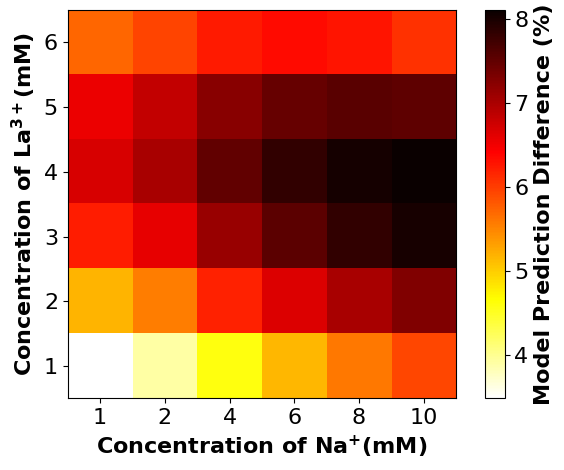

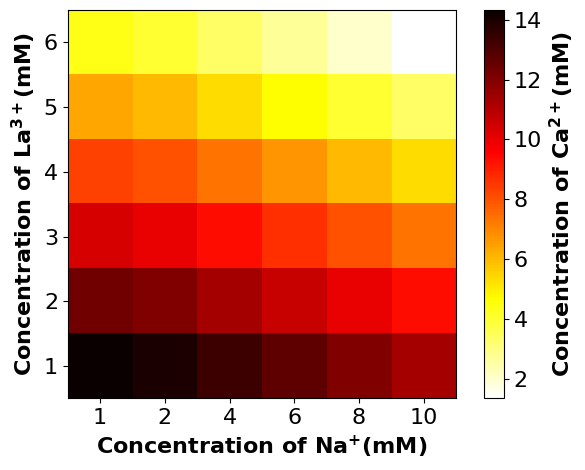

In [13]:
# desired ionic strength in mM
ionic_strength_50 = 50

# cation concentration in mM
na_50 = [1, 2, 4, 6, 8, 10]
la_50 = [6, 5, 4, 3, 2, 1]

three_salts_conc(la_50, na_50, ionic_strength_50, "ionic_str_50")

### 100 mM Ionic Strength

The concentration of NaCl is: 4
The concentration of LaCl3 is: 12
The concentration of CaCl2 is: 8.0
The ionic strength of Na+ is: 2.0
The ionic strength of La3+ is: 54.0
The ionic strength of Ca2+ is: 16.0
The ionic strength of Cl- is: 28.0
Relaxation correction: [-0.1278413  -0.05379197 -0.01517213 -0.09863655]
Hydrodynamic correction: [-0.32762445 -0.25992877 -0.15406733 -0.09488889]
omega_bar: 256619901898.05518
Alpha: [0.0, 180981633934.03104, 309370304281.88446, 366430799797.4742]
Mew: [0.54 0.16 0.02 0.28]
Transport number: [0.31634836 0.11992959 0.02525033 0.53847173]
Omega: [1.50335711e+11 1.92351992e+11 3.23986816e+11 4.93509152e+11]
ksi: [[ 1.49904316 -0.82891105 -0.32696842 -0.34632344]
 [ 1.17160065  2.53681075 -0.52094863 -0.50870587]
 [ 0.695583    0.25117359  5.56481072 -2.84418812]
 [ 0.4566475   0.13106707  0.53078041  1.16175486]]
The concentration of NaCl is: 4
The concentration of LaCl3 is: 10
The concentration of CaCl2 is: 12.0
The ionic strength of Na+ is: 2.0
Th

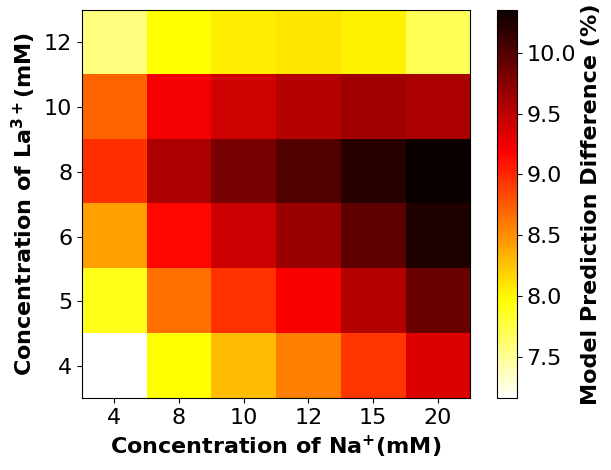

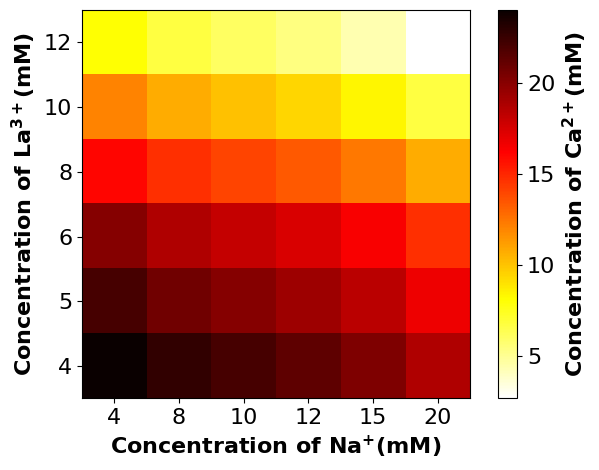

In [14]:
# data in mM
ionic_strength_100 = 100

# cation concentration in mM
na_100 = [4, 8, 10, 12, 15, 20]
la_100 = [12, 10, 8, 6, 5, 4]

three_salts_conc(la_100, na_100, ionic_strength_100, "ionic_str_100")


### 150 mM Ionic Strength

The concentration of NaCl is: 8
The concentration of LaCl3 is: 14
The concentration of CaCl2 is: 19.333333333333332
The ionic strength of Na+ is: 4.0
The ionic strength of La3+ is: 63.0
The ionic strength of Ca2+ is: 38.666666666666664
The ionic strength of Cl- is: 44.33333333333333
Relaxation correction: [-0.15451096 -0.06882576 -0.02078793 -0.10507925]
Hydrodynamic correction: [-0.38399201 -0.3054738  -0.18100712 -0.11031895]
omega_bar: 267224088060.83624
Alpha: [0.0, 174068858834.9997, 306457439300.934, 367920464514.2693]
Mew: [0.42       0.25777778 0.02666667 0.29555556]
Transport number: [0.23628483 0.18555239 0.0323311  0.54583168]
Omega: [1.50335711e+11 1.92351992e+11 3.23986816e+11 4.93509152e+11]
ksi: [[ 1.56701821 -1.24346353 -0.34705788 -0.33163754]
 [ 1.22472761  1.8284331  -0.55638876 -0.48643562]
 [ 0.72712464  0.27631788  4.82655065 -2.65128638]
 [ 0.47735446  0.14737258  0.54298066  1.13474785]]
The concentration of NaCl is: 8
The concentration of LaCl3 is: 12
The conce

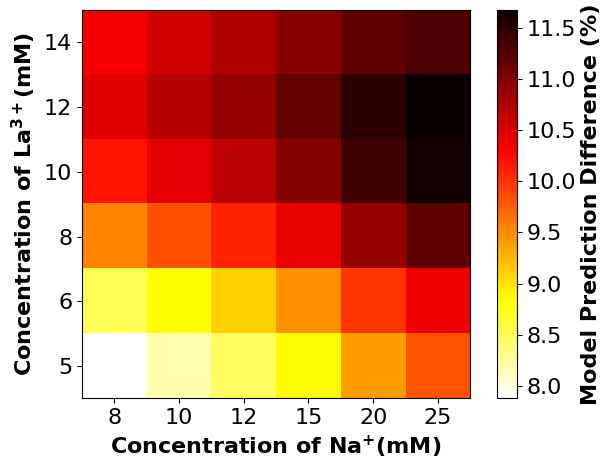

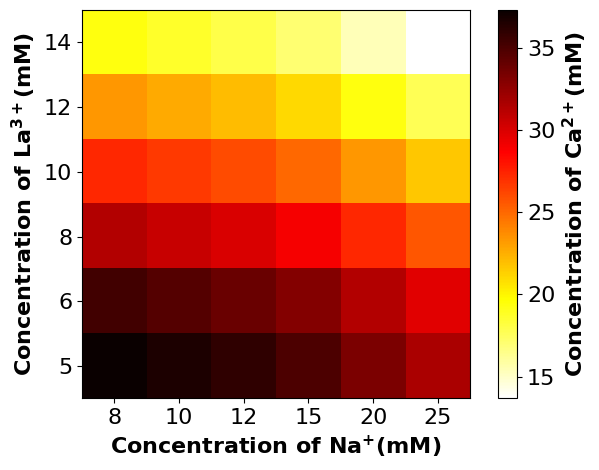

In [15]:
# desired ionic strength in mM
ionic_strength_150 = 150

# cation concentration in mM
na_150 = [8, 10, 12, 15, 20, 25]
la_150 = [14, 12, 10, 8, 6, 5]

results_150 = three_salts_conc(la_150, na_150, ionic_strength_150, "ionic_str_150")

### 200 mM Ionic Strength

The concentration of NaCl is: 10
The concentration of LaCl3 is: 16
The concentration of CaCl2 is: 31.333333333333332
The ionic strength of Na+ is: 5.0
The ionic strength of La3+ is: 72.0
The ionic strength of Ca2+ is: 62.666666666666664
The ionic strength of Cl- is: 60.33333333333333
Relaxation correction: [-0.17101573 -0.07790599 -0.02408007 -0.11048341]
Hydrodynamic correction: [-0.42792877 -0.34115043 -0.20209769 -0.12218528]
omega_bar: 271366078426.5866
Alpha: [0.0, 170452699924.02408, 307822470104.9732, 367200682694.58984]
Mew: [0.36       0.31333333 0.025      0.30166667]
Transport number: [0.19943855 0.22209958 0.02984776 0.54861412]
Omega: [1.50335711e+11 1.92351992e+11 3.23986816e+11 4.93509152e+11]
ksi: [[ 1.59628912 -1.49795204 -0.33192466 -0.33451847]
 [ 1.24760476  1.55672214 -0.53056801 -0.49100009]
 [ 0.74070687  0.27442689  5.05382336 -2.70892247]
 [ 0.48627115  0.14794185  0.52837106  1.13368974]]
The concentration of NaCl is: 10
The concentration of LaCl3 is: 14
The c

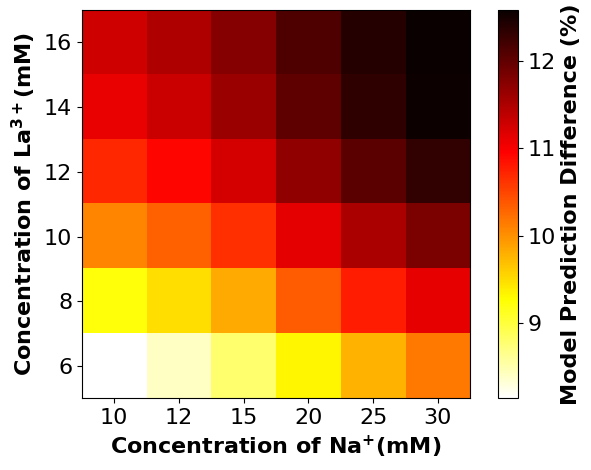

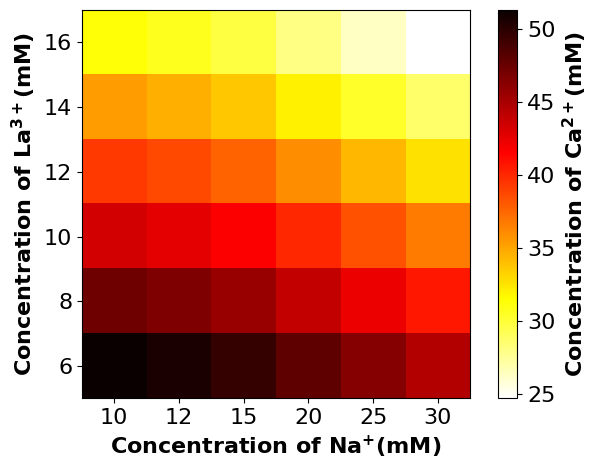

In [16]:
# desired ionic strength in mM
ionic_strength_200 = 200

# cation concentration in mM
na_200 = [10, 12, 15, 20, 25, 30]
la_200 = [16, 14, 12, 10, 8, 6]

three_salts_conc(la_200, na_200, ionic_strength_200, "ionic_str_200")

### 250 mM Ionic Strength

The concentration of NaCl is: 12
The concentration of LaCl3 is: 18
The concentration of CaCl2 is: 43.333333333333336
The ionic strength of Na+ is: 6.0
The ionic strength of La3+ is: 81.0
The ionic strength of Ca2+ is: 86.66666666666667
The ionic strength of Cl- is: 76.33333333333334
Relaxation correction: [-0.18271236 -0.08436168 -0.02641653 -0.11459484]
Hydrodynamic correction: [-0.46416906 -0.37069646 -0.21955586 -0.13187163]
omega_bar: 273851272646.03687
Alpha: [0.0, 168325850760.34158, 308611688011.4316, 366772534987.3379]
Mew: [0.324      0.34666667 0.024      0.30533333]
Transport number: [0.17786578 0.24349722 0.02839382 0.55024318]
Omega: [1.50335711e+11 1.92351992e+11 3.23986816e+11 4.93509152e+11]
ksi: [[ 1.61420706 -1.67303074 -0.32315351 -0.33629218]
 [ 1.2616088   1.41611709 -0.51568667 -0.49380757]
 [ 0.74902112  0.26971965  5.20121834 -2.74453615]
 [ 0.49172941  0.14629289  0.51957601  1.13323414]]
The concentration of NaCl is: 12
The concentration of LaCl3 is: 16
The co

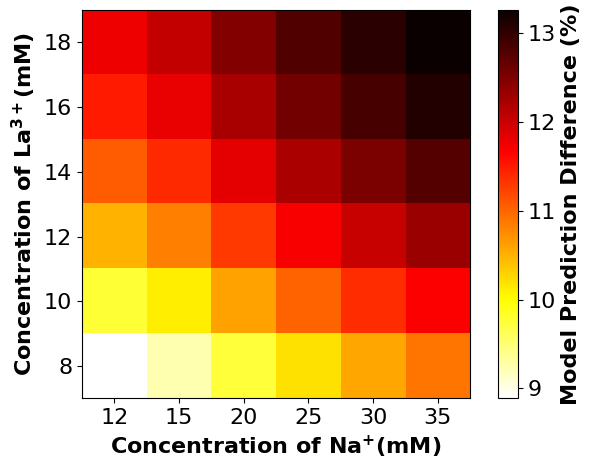

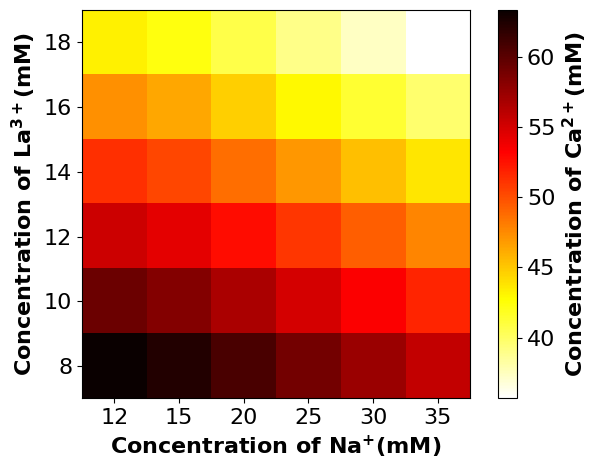

In [17]:
# desired ionic strength in mM
ionic_strength_250 = 250

# cation concentration in mM
na_250 = [12, 15, 20, 25, 30, 35]
la_250 = [18, 16, 14, 12, 10, 8]

three_salts_conc(la_250, na_250, ionic_strength_250, "ionic_str_250")
